### Домашнее задание 20

Реализуйте RANSAC для парабол по примеру с семинара. То, как это сделать, было достаточно подробно обсуждено в конце занятия. Умоляю, не надо пользоваться LLM для написания кода, в этом не будет никакого смысла

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [216]:
from types import NotImplementedType
# sklearn style

class RANSAC:
    def __init__(self, max_iter: int = 100, thr = 0.1):

        self.num_points = 3
        self.thr = thr
        self.max_iter = max_iter
        self.x, self.y = None, None
        self.n = None
        self.x_matrix = None
        self.x_label = None
        self.y_label = None
        self.best_params = None

    def fit(self, data: np.array, draw: bool = True):
        self.x, self.y = data[:, 0], data[:, 1]
        self.n = data.shape[0]
        self.x_matrix = np.vstack([self.x**2, self.x, np.ones(self.n)]).T


        best_metric = float('-inf')
        k = 1

        for i in range(self.max_iter):

            indexes = np.random.choice(self.n, size=self.num_points, replace=False)
            x, y = self.x[indexes], self.y[indexes]

            # get params of the parabola

            params = np.linalg.solve(self.x_matrix[indexes, :], y).reshape(-1, 1)

            # calculate all dots
            y_pred = self.x_matrix @ params

            # calculate errir
            errors = (self.y - y_pred.flatten())**2
            is_inlier = errors <= self.thr

            # calculated % of inliers
            metric = is_inlier.sum() / self.n

            if metric > best_metric:
                best_metric = metric
                self.best_params = params

            if draw and i+1 == k*(self.max_iter // 5):  # эта штука короче рисует максимум 5 графиков на все итерации (равномерно распределенные)
                k += 1
                self.draw(self.x, self.x_matrix @ self.best_params, self.y, title = f'training progress on iter = {i+1}', params = self.best_params)


    def predict(self, data: np.array, y_true = None, draw: bool = True):

        x = data
        n = data.shape[0]
        x_matrix = np.vstack([x**2, x, np.ones(n)]).T

        y_pred = x_matrix @ self.best_params

        if draw:
            self.draw(x, y_pred, y_true, title = f'predictions', params = self.best_params)

        return y_pred

    def fit_predict(self, data: np.array):
        self.fit(data)

        return self.predict(data)

    def draw(self, x: np.array, y_pred: np.array, y: np.array = np.array([]), title: str = '', params: np.array = None):
        idx = np.argsort(x)
        if len(y) > 0:
            plt.scatter(x, y.flatten())
        plt.plot(x.flatten()[idx], y_pred.flatten()[idx], label = f'{params[0][0]:.3f}x^2 + {params[1][0]:.3f}x + {params[2][0]:.3f}', c = 'red', lw = 3)
        plt.title(title)
        plt.legend()
        plt.show()

In [217]:
x = 3*np.random.randn(300)
y = 1.4*x**2 - 3.1*x + 8.31 + np.random.randn(300)

data = np.vstack([x, y]).T

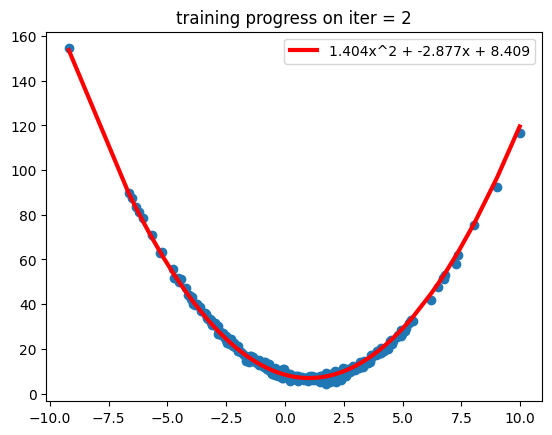

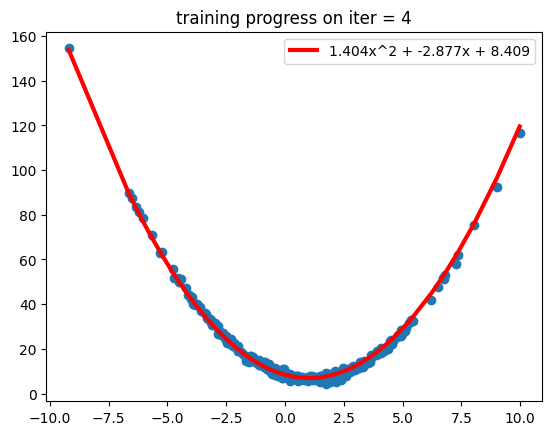

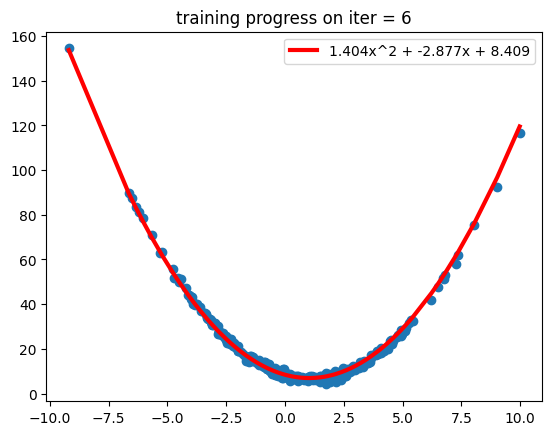

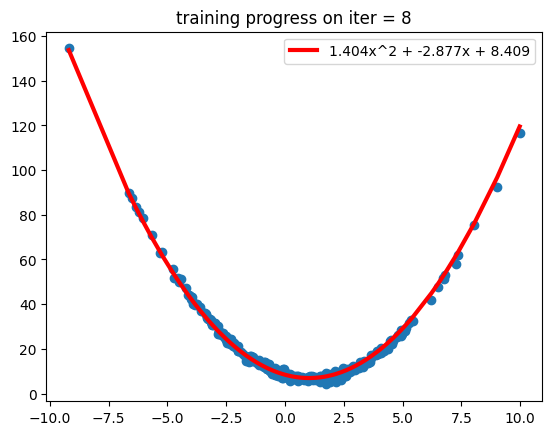

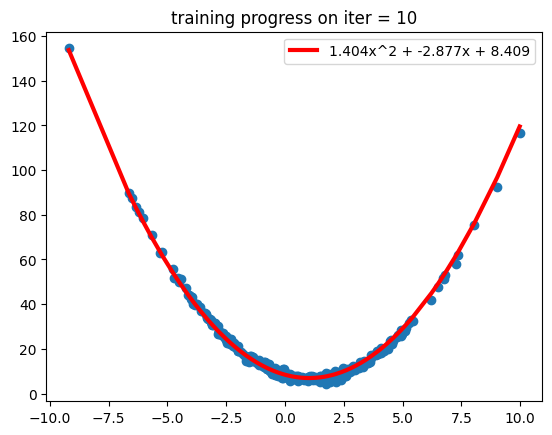

In [218]:
ransac = RANSAC(max_iter = 10, thr = 0.1)
ransac.fit(data)

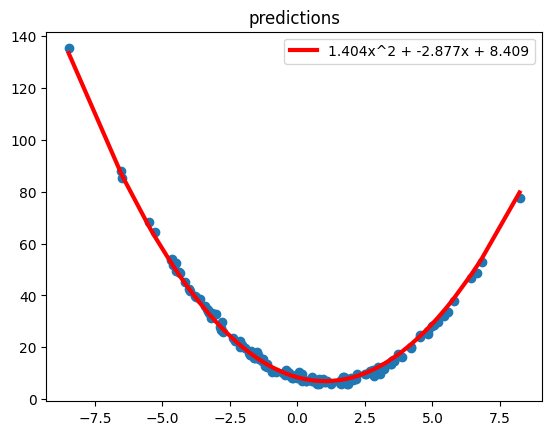

In [219]:
x = 3*np.random.randn(150)
y = 1.4*x**2 - 3.1*x + 8.31 + np.random.randn(150)

y_pred = ransac.predict(x, y)